# XGBoost + Feature Engineering — Full Dataset
**DS340 — Parent Genre Classification**

Key improvements over baseline DNN (42.3%):
1. **Full dataset** — use all ~113k rows, not a 12k sample
2. **Feature engineering** — log transforms + genre-discriminating interactions
3. **XGBoost** — gradient boosted trees outperform DNNs on tabular audio features
4. **Class weights** — handle imbalanced genre distribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import VotingClassifier

import xgboost as xgb
import lightgbm as lgb

print('Libraries loaded.')
print(f'XGBoost version: {xgb.__version__}')
print(f'LightGBM version: {lgb.__version__}')

Libraries loaded.
XGBoost version: 3.2.0
LightGBM version: 4.6.0


---
## 1. Load Full Dataset (no sampling cap)

In [2]:
GENRE_MAP = {
    'rock': 'Rock', 'alt-rock': 'Rock', 'punk-rock': 'Rock',
    'hard-rock': 'Rock', 'psych-rock': 'Rock', 'grunge': 'Rock',
    'rock-n-roll': 'Rock', 'emo': 'Rock', 'indie': 'Rock',
    'alternative': 'Rock', 'rockabilly': 'Rock', 'punk': 'Rock',
    'metal': 'Metal', 'heavy-metal': 'Metal', 'death-metal': 'Metal',
    'black-metal': 'Metal', 'metalcore': 'Metal', 'grindcore': 'Metal',
    'hardcore': 'Metal', 'goth': 'Metal', 'industrial': 'Metal',
    'edm': 'Electronic', 'electronic': 'Electronic', 'techno': 'Electronic',
    'detroit-techno': 'Electronic', 'minimal-techno': 'Electronic',
    'trance': 'Electronic', 'dubstep': 'Electronic', 'drum-and-bass': 'Electronic',
    'idm': 'Electronic', 'electro': 'Electronic', 'breakbeat': 'Electronic',
    'hardstyle': 'Electronic', 'ambient': 'Electronic',
    'house': 'House/Dance', 'deep-house': 'House/Dance',
    'chicago-house': 'House/Dance', 'progressive-house': 'House/Dance',
    'dance': 'House/Dance', 'disco': 'House/Dance', 'club': 'House/Dance',
    'garage': 'House/Dance', 'dancehall': 'House/Dance',
    'pop': 'Pop', 'indie-pop': 'Pop', 'synth-pop': 'Pop',
    'power-pop': 'Pop', 'k-pop': 'Pop', 'j-pop': 'Pop',
    'cantopop': 'Pop', 'mandopop': 'Pop', 'j-idol': 'Pop',
    'j-dance': 'Pop', 'party': 'Pop', 'happy': 'Pop',
    'pop-film': 'Pop', 'disney': 'Pop', 'show-tunes': 'Pop',
    'hip-hop': 'Hip-Hop/R&B', 'r-n-b': 'Hip-Hop/R&B', 'soul': 'Hip-Hop/R&B',
    'funk': 'Hip-Hop/R&B', 'groove': 'Hip-Hop/R&B', 'trip-hop': 'Hip-Hop/R&B',
    'latin': 'Latin', 'latino': 'Latin', 'salsa': 'Latin',
    'samba': 'Latin', 'reggaeton': 'Latin', 'tango': 'Latin',
    'forro': 'Latin', 'pagode': 'Latin', 'sertanejo': 'Latin',
    'mpb': 'Latin', 'brazil': 'Latin', 'bossanova': 'Latin',
    'romance': 'Latin', 'spanish': 'Latin',
    'jazz': 'Jazz/Blues', 'blues': 'Jazz/Blues', 'gospel': 'Jazz/Blues',
    'classical': 'Classical/Instrumental', 'opera': 'Classical/Instrumental',
    'piano': 'Classical/Instrumental', 'guitar': 'Classical/Instrumental',
    'new-age': 'Classical/Instrumental', 'sleep': 'Classical/Instrumental',
    'study': 'Classical/Instrumental',
    'country': 'Country/Folk', 'folk': 'Country/Folk', 'bluegrass': 'Country/Folk',
    'honky-tonk': 'Country/Folk', 'singer-songwriter': 'Country/Folk',
    'songwriter': 'Country/Folk', 'acoustic': 'Country/Folk',
    'reggae': 'Reggae', 'dub': 'Reggae', 'ska': 'Reggae',
    'world-music': 'World/Other', 'afrobeat': 'World/Other',
    'indian': 'World/Other', 'iranian': 'World/Other',
    'turkish': 'World/Other', 'malay': 'World/Other',
    'french': 'World/Other', 'german': 'World/Other',
    'swedish': 'World/Other', 'british': 'World/Other',
    'j-rock': 'World/Other', 'anime': 'World/Other',
    'children': 'World/Other', 'kids': 'World/Other',
    'comedy': 'World/Other', 'sad': 'World/Other',
    'chill': 'World/Other',
}

data = pd.read_csv('../Data/spotify-tracks-dataset.csv')
drop_cols = ['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']
data = data.drop(columns=[c for c in drop_cols if c in data.columns])
data = data.dropna().drop_duplicates()

data['parent_genre'] = data['track_genre'].map(GENRE_MAP).fillna('World/Other')

print(f'Full dataset shape: {data.shape}')
print(f'\nParent genre distribution:')
print(data['parent_genre'].value_counts())

Full dataset shape: (106907, 17)

Parent genre distribution:
parent_genre
World/Other               16581
Pop                       14398
Electronic                12494
Latin                     12175
Rock                      10784
Metal                      8845
House/Dance                8270
Classical/Instrumental     6738
Country/Folk               6287
Hip-Hop/R&B                5223
Reggae                     2781
Jazz/Blues                 2331
Name: count, dtype: int64


---
## 2. Feature Engineering
Key insight: Spotify's raw features overlap heavily between similar genres.
Interactions and transforms create new separating dimensions.

In [3]:
def engineer_features(df):
    d = df.copy()
    d['explicit'] = d['explicit'].astype(int)

    # Log transforms for heavily right-skewed features
    d['log_speechiness']      = np.log1p(d['speechiness'])
    d['log_instrumentalness'] = np.log1p(d['instrumentalness'])
    d['log_liveness']         = np.log1p(d['liveness'])
    d['log_acousticness']     = np.log1p(d['acousticness'])
    d['duration_min']         = d['duration_ms'] / 60000

    # Loudness normalized to 0-1
    d['loudness_norm'] = (d['loudness'] + 60) / 60

    # Genre-discriminating interactions
    d['energy_x_loudness']       = d['energy'] * d['loudness_norm']
    d['dance_x_tempo']           = d['danceability'] * d['tempo'] / 200
    d['acoustic_x_instrumental'] = d['acousticness'] * d['instrumentalness']
    d['speech_x_energy']         = d['speechiness'] * d['energy']
    d['valence_x_dance']         = d['valence'] * d['danceability']
    d['energy_minus_acoustic']   = d['energy'] - d['acousticness']

    # Binary flags
    d['is_instrumental'] = (d['instrumentalness'] > 0.5).astype(int)
    d['is_spoken']       = (d['speechiness'] > 0.33).astype(int)
    d['is_acoustic']     = (d['acousticness'] > 0.6).astype(int)
    d['is_live']         = (d['liveness'] > 0.8).astype(int)

    # Tempo buckets — include_lowest=True covers tempo=0 edge case
    d['tempo_bucket'] = pd.cut(
        d['tempo'], bins=[0, 90, 130, 180, 999],
        labels=[0, 1, 2, 3], include_lowest=True
    ).astype(int)

    return d

data = engineer_features(data)

feature_cols = [
    # original
    'popularity', 'duration_min', 'explicit',
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature',
    # log transforms
    'log_speechiness', 'log_instrumentalness', 'log_liveness', 'log_acousticness',
    # interactions
    'loudness_norm', 'energy_x_loudness', 'dance_x_tempo',
    'acoustic_x_instrumental', 'speech_x_energy', 'valence_x_dance',
    'energy_minus_acoustic',
    # binary flags
    'is_instrumental', 'is_spoken', 'is_acoustic', 'is_live',
    # tempo bucket
    'tempo_bucket',
]

le = LabelEncoder()
y = le.fit_transform(data['parent_genre'])
X = data[feature_cols].copy()
num_classes = len(le.classes_)

del data
gc.collect()

print(f'Features: {X.shape[1]}')
print(f'Samples: {X.shape[0]:,}')
print(f'Classes: {num_classes} — {list(le.classes_)}')

Features: 31
Samples: 106,907
Classes: 12 — ['Classical/Instrumental', 'Country/Folk', 'Electronic', 'Hip-Hop/R&B', 'House/Dance', 'Jazz/Blues', 'Latin', 'Metal', 'Pop', 'Reggae', 'Rock', 'World/Other']


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

del X, X_temp, y_temp
gc.collect()

print(f'Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

Train: 74,834  Val: 16,036  Test: 16,037


---
## 3. Train XGBoost

In [5]:
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
sample_weights = np.array([weights[c] for c in y_train])

# Tuned XGBoost — deeper trees, lower LR, more estimators
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='multi:softprob',   # softprob for ensemble probability averaging
    num_class=num_classes,
    eval_metric='mlogloss',
    early_stopping_rounds=40,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

print('Training XGBoost...')
xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

xgb_val_proba = xgb_model.predict_proba(X_val)
xgb_val_preds = xgb_val_proba.argmax(axis=1)
xgb_acc = accuracy_score(y_val, xgb_val_preds)
xgb_f1  = f1_score(y_val, xgb_val_preds, average='macro')
print(f'\nXGBoost — Val Accuracy: {xgb_acc:.4f}, Macro F1: {xgb_f1:.4f}')

Training XGBoost...
[0]	validation_0-mlogloss:2.43494
[100]	validation_0-mlogloss:1.58614
[200]	validation_0-mlogloss:1.50917
[300]	validation_0-mlogloss:1.47841
[400]	validation_0-mlogloss:1.46151
[500]	validation_0-mlogloss:1.45334
[600]	validation_0-mlogloss:1.45197
[631]	validation_0-mlogloss:1.45294

XGBoost — Val Accuracy: 0.4994, Macro F1: 0.4653


---
## 4. Train LightGBM
LightGBM uses leaf-wise tree growth (vs XGBoost's depth-wise), which is better at capturing complex patterns in tabular data.

In [6]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=8,
    num_leaves=63,           # 2^(max_depth-1) — controls model complexity
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

print('Training LightGBM...')
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=40, verbose=False),
        lgb.log_evaluation(period=100),
    ],
)

lgb_val_proba = lgb_model.predict_proba(X_val)
lgb_val_preds = lgb_val_proba.argmax(axis=1)
lgb_acc = accuracy_score(y_val, lgb_val_preds)
lgb_f1  = f1_score(y_val, lgb_val_preds, average='macro')
print(f'\nLightGBM — Val Accuracy: {lgb_acc:.4f}, Macro F1: {lgb_f1:.4f}')

Training LightGBM...
[100]	valid_0's multi_logloss: 1.55301
[200]	valid_0's multi_logloss: 1.50151
[300]	valid_0's multi_logloss: 1.47869
[400]	valid_0's multi_logloss: 1.46908
[500]	valid_0's multi_logloss: 1.46717

LightGBM — Val Accuracy: 0.4974, Macro F1: 0.4646


---
## 5. Soft-Voting Ensemble (XGBoost + LightGBM)
Average the predicted probabilities from both models — errors from one model are often corrected by the other.

In [7]:
# Soft voting: average probabilities (gives more weight to confident predictions)
ensemble_proba = (xgb_val_proba + lgb_val_proba) / 2
ensemble_preds = ensemble_proba.argmax(axis=1)

ens_acc = accuracy_score(y_val, ensemble_preds)
ens_f1  = f1_score(y_val, ensemble_preds, average='macro')
print(f'Ensemble (XGB + LGB) — Val Accuracy: {ens_acc:.4f}, Macro F1: {ens_f1:.4f}')

Ensemble (XGB + LGB) — Val Accuracy: 0.5011, Macro F1: 0.4674


---
## 4. Results vs Baselines

In [8]:
results = pd.DataFrame([
    {'Model': 'Random Forest (baseline, 12k)',      'Accuracy': 0.3019, 'Macro F1': 0.2834},
    {'Model': 'NN-C DNN (3 layers, 12k)',           'Accuracy': 0.4233, 'Macro F1': 0.4120},
    {'Model': 'XGBoost v1 (full data)',             'Accuracy': 0.4945, 'Macro F1': 0.4644},
    {'Model': 'XGBoost v2 (tuned)',                 'Accuracy': xgb_acc, 'Macro F1': xgb_f1},
    {'Model': 'LightGBM',                           'Accuracy': lgb_acc, 'Macro F1': lgb_f1},
    {'Model': 'Ensemble (XGB + LGB)',               'Accuracy': ens_acc, 'Macro F1': ens_f1},
])

print('=== Model Comparison — Validation Set ===')
print(results.to_string(index=False))

=== Model Comparison — Validation Set ===
                        Model  Accuracy  Macro F1
Random Forest (baseline, 12k)  0.301900  0.283400
     NN-C DNN (3 layers, 12k)  0.423300  0.412000
       XGBoost v1 (full data)  0.494500  0.464400
           XGBoost v2 (tuned)  0.499439  0.465335
                     LightGBM  0.497381  0.464648
         Ensemble (XGB + LGB)  0.501060  0.467375


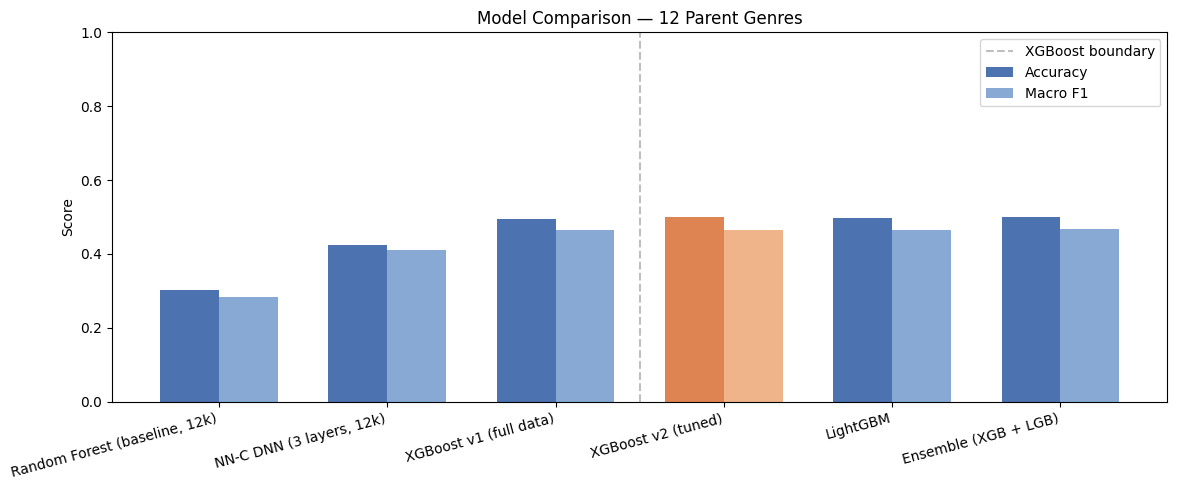

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results))
w = 0.35
ax.bar(x - w/2, results['Accuracy'], w, label='Accuracy', color=['#4C72B0','#4C72B0','#4C72B0','#DD8452'])
ax.bar(x + w/2, results['Macro F1'], w, label='Macro F1',  color=['#87a9d4','#87a9d4','#87a9d4','#f0b48a'])
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — 12 Parent Genres')
ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5, label='XGBoost boundary')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Feature Importance

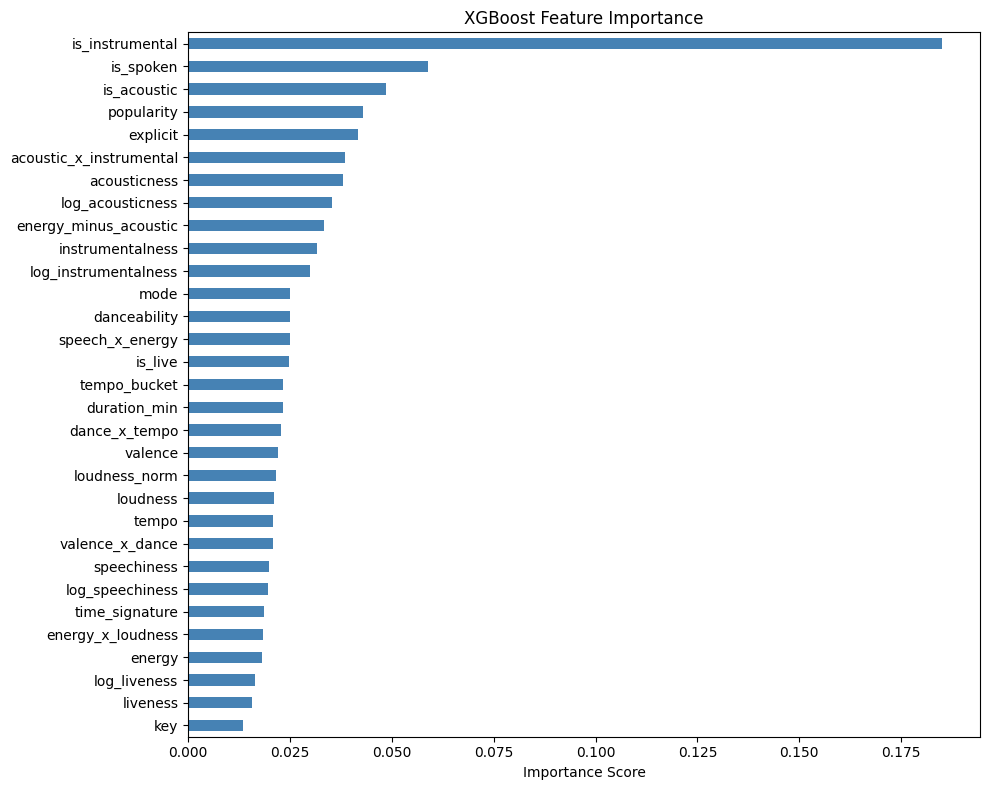

In [10]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

---
## 6. Classification Report & Confusion Matrix

In [11]:
print('=== Best Model: Ensemble ===')
print(classification_report(y_val, ensemble_preds, target_names=le.classes_))

=== Best Model: Ensemble ===
                        precision    recall  f1-score   support

Classical/Instrumental       0.65      0.76      0.70      1011
          Country/Folk       0.45      0.60      0.51       943
            Electronic       0.61      0.54      0.57      1874
           Hip-Hop/R&B       0.29      0.31      0.30       784
           House/Dance       0.38      0.45      0.41      1240
            Jazz/Blues       0.25      0.35      0.29       350
                 Latin       0.61      0.59      0.60      1826
                 Metal       0.62      0.67      0.64      1327
                   Pop       0.55      0.48      0.51      2160
                Reggae       0.14      0.24      0.17       417
                  Rock       0.44      0.43      0.44      1617
           World/Other       0.58      0.39      0.46      2487

              accuracy                           0.50     16036
             macro avg       0.46      0.48      0.47     16036
         

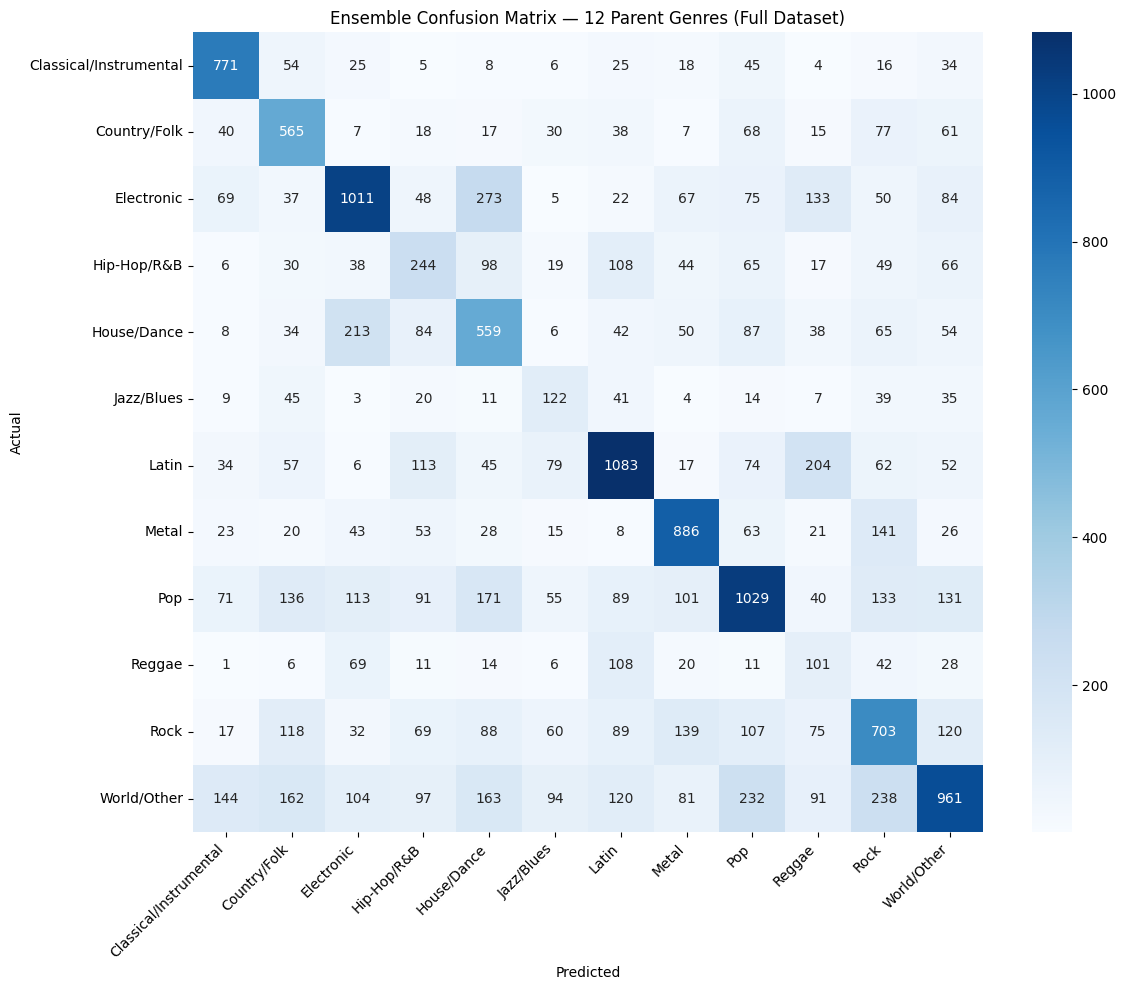

In [12]:
cm = confusion_matrix(y_val, ensemble_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title('Ensemble Confusion Matrix — 12 Parent Genres (Full Dataset)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 7. Test Set — Final Score
Run only once when done tuning.

In [13]:
xgb_test_proba = xgb_model.predict_proba(X_test)
lgb_test_proba = lgb_model.predict_proba(X_test)
ens_test_preds = ((xgb_test_proba + lgb_test_proba) / 2).argmax(axis=1)

print('Ensemble (XGB + LGB) — TEST SET')
print(f'Accuracy : {accuracy_score(y_test, ens_test_preds):.4f}')
print(f'Macro F1 : {f1_score(y_test, ens_test_preds, average="macro"):.4f}')

Ensemble (XGB + LGB) — TEST SET
Accuracy : 0.5031
Macro F1 : 0.4684


## AI Usage
- Used Claude to implement XGBoost pipeline with feature engineering
- Research informed by: Analytics Vidhya Spotify genre classification benchmark (XGBoost 73%+), Stanford CS229 Spotify genre classification paper